# Planteamiento del Problema:

Clasificador de Vinos con KNN
Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

Utilizaremos el siguiente dataset de vinos tintos extraido de Wine Quality Data Set - UCI

https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv

Descripción de las columnas
Cada fila representa un vino. Las columnas describen su composición química:

- fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol

La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

### Paso 1: Cargamos los datos y exploramos su estructura.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv",sep=';')
total_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [46]:
total_data.shape

(1599, 12)

In [47]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [48]:
# Estadísticas descriptivas de cada variable
total_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [49]:
# Verificamos valores nulos explícitamente
total_data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [50]:
# Verificamos duplicados
total_data.duplicated().sum()

np.int64(240)

In [51]:
# Eliminamos las filas duplicadas
total_data = total_data.drop_duplicates().reset_index(drop=True)
total_data.shape

(1359, 12)

In [52]:
# Volvemos a verificar duplicados
total_data.duplicated().sum()

np.int64(0)

In [53]:
# Distribución de la variable objetivo original
total_data['quality'].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

In [54]:
# Función para clasificar la calidad en 3 categorías
def clasificar_calidad(q):
    if q <= 4:
        return 0  # Baja calidad
    elif q <= 6:
        return 1  # Calidad media
    else:
        return 2  # Alta calidad

total_data['label'] = total_data['quality'].apply(clasificar_calidad)

# Vemos cómo queda la nueva distribución
total_data['label'].value_counts().sort_index()

label
0      63
1    1112
2     184
Name: count, dtype: int64

In [55]:
total_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,1


### Paso 2 Entrena el modelo KNN:

- Separar las variables independientes (X) del objetivo (y).
- Dividir en conjunto de entrenamiento y prueba (80/20).
- Escalar los datos si es necesario (¡muy recomendable con KNN!).
- Entrenar el modelo con un valor de k inicial.

In [56]:
from sklearn.model_selection import train_test_split

# Separamos variables independientes (X) del objetivo (y)
X = total_data.drop(columns=['quality', 'label'])
y = total_data['label']

# Dividimos en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((1087, 11), (272, 11))

In [57]:
from sklearn.preprocessing import StandardScaler

# Escalado — muy importante en KNN porque se basa en distancias
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Entrenamos con un valor de k inicial (ej. k=5)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8198529411764706


### Paso 3 Evaluamos el rendimiento usando:

- Accuracy_score
- Confusion_matrix
- Classification_report

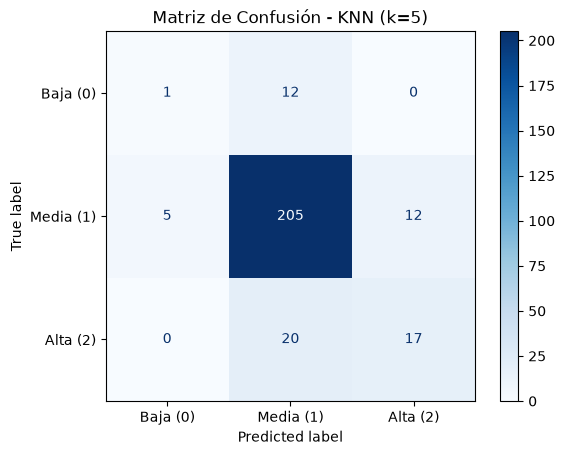

In [59]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - KNN (k=5)")
plt.show()

- Fila "Baja (0)" (13 vinos de baja calidad reales): el modelo solo acertó 1, y confundió 12 con "Media". Es decir, casi nunca detecta un vino de baja calidad — los clasifica como medios.
- Fila "Media (1)" (222 vinos): acertó 205, confundió 5 con "Baja" y 12 con "Alta". Esta clase la predice muy bien.
- Fila "Alta (2)" (37 vinos): acertó 17, pero confundió 20 con "Media" (más de la mitad). También le cuesta bastante.

Patrón claro: el modelo casi siempre "cae" hacia la clase Media cuando duda. Tiene sentido — es la clase mayoritaria (82% de los datos), así que estadísticamente predecir "Media" es la apuesta más segura para el algoritmo.

In [60]:
# Reporte de clasificación (precision, recall, f1-score por clase)
print(classification_report(y_test, y_pred, target_names=['Baja (0)', 'Media (1)', 'Alta (2)']))

              precision    recall  f1-score   support

    Baja (0)       0.17      0.08      0.11        13
   Media (1)       0.86      0.92      0.89       222
    Alta (2)       0.59      0.46      0.52        37

    accuracy                           0.82       272
   macro avg       0.54      0.49      0.50       272
weighted avg       0.79      0.82      0.80       272



- Support: cuántos ejemplos reales de esa clase había en el test (13, 222, 37 — coincide con las filas de la matriz).
- Recall ("de todos los que realmente eran de esta clase, ¿a cuántos detectó?"):
    Baja: recall 0.08 → de 13 vinos reales de baja calidad, solo detectó 1/13 ≈ 8%.
    Alta: recall 0.46 → de 37, detectó 17/37 ≈ 46%.
    Media: recall 0.92 → detecta case todos.
- Precision ("de todos los que predije como esta clase, ¿cuántos acerté?"):
    Baja: precision 0.17 → cuando el modelo dijo "Baja", solo acertó 17% de las veces (predijo Baja muy pocas veces en total: 1+5+0=6 veces, y solo 1 fue correcto → 1/6≈0.17).
- F1-score: Es baja (0.11) para "Baja" porque tanto precision como recall son bajas ahí.
- Accuracy (0.82): como se ve, ese 82% está "inflado" por la clase Media, que domina el dataset.
- Macro avg (0.50 en f1): promedio simple de las 3 clases, sin importar su tamaño. Este es el número que mejor refleja qué tan bien funciona el modelo para las 3 clases por igual — y aquí vemos que 0.50 es bastante mediocre, muy lejos del 0.82 de accuracy.
- Weighted avg (0.80 en f1): promedio ponderado por el tamaño de cada clase — por eso se parece mucho al accuracy, porque está dominado por la clase Media.

## Conclusión:
El accuracy de 0.82 es engañoso, en realidad el modelo funciona muy bien solo para la clase Media y muy mal para Baja y Alta.

### Paso 4 Optimización de k. Crea un bucle para probar diferentes valores de k (por ejemplo, de 1 a 20).

- Guarda los resultados en una lista.
- Grafica accuracy vs k para encontrar el mejor valor.

In [61]:
# Bucle para probar diferentes valores de k
accuracy_scores = []
k_values = range(1, 21)

for k in k_values:
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train_scaled, y_train)
    y_pred_k = model_k.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracy_scores.append(acc)

# Vemos los resultados en una tabla rápida
for k, acc in zip(k_values, accuracy_scores):
    print(f"k={k:2d}  ->  accuracy={acc:.4f}")

k= 1  ->  accuracy=0.7757
k= 2  ->  accuracy=0.7941
k= 3  ->  accuracy=0.8235
k= 4  ->  accuracy=0.8125
k= 5  ->  accuracy=0.8199
k= 6  ->  accuracy=0.8125
k= 7  ->  accuracy=0.8419
k= 8  ->  accuracy=0.8309
k= 9  ->  accuracy=0.8419
k=10  ->  accuracy=0.8272
k=11  ->  accuracy=0.8346
k=12  ->  accuracy=0.8419
k=13  ->  accuracy=0.8309
k=14  ->  accuracy=0.8382
k=15  ->  accuracy=0.8346
k=16  ->  accuracy=0.8456
k=17  ->  accuracy=0.8456
k=18  ->  accuracy=0.8493
k=19  ->  accuracy=0.8529
k=20  ->  accuracy=0.8493


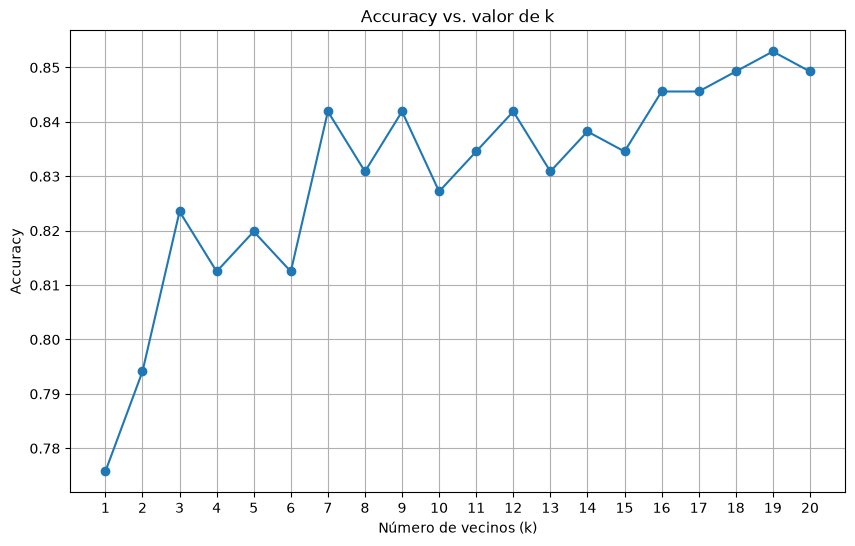

In [62]:
# Graficamos accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-')
plt.title("Accuracy vs. valor de k")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [63]:
# Identificamos el mejor k según accuracy
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print(f"El mejor valor de k es {best_k} con un accuracy de {max(accuracy_scores):.4f}")

El mejor valor de k es 19 con un accuracy de 0.8529


In [64]:
# Entrenamos el modelo final con k=19
best_model = KNeighborsClassifier(n_neighbors=19)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best))

Accuracy: 0.8529411764705882


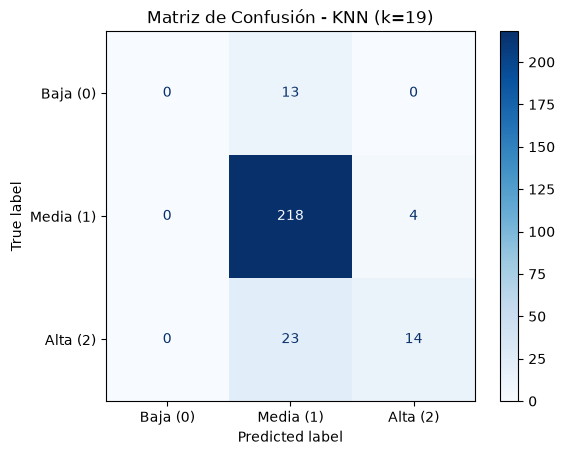

In [65]:
# Matriz de confusión con k=19
cm_best = confusion_matrix(y_test, y_pred_best)

disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp_best.plot(cmap='Blues')
plt.title("Matriz de Confusión - KNN (k=19)")
plt.show()

In [66]:
# Reporte de clasificación con k=19
print(classification_report(y_test, y_pred_best, target_names=['Baja (0)', 'Media (1)', 'Alta (2)']))

              precision    recall  f1-score   support

    Baja (0)       0.00      0.00      0.00        13
   Media (1)       0.86      0.98      0.92       222
    Alta (2)       0.78      0.38      0.51        37

    accuracy                           0.85       272
   macro avg       0.55      0.45      0.48       272
weighted avg       0.81      0.85      0.82       272



/home/vscode/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Conclusiones:
Aunque optimizar k mediante el bucle de 1 a 20 llevó el accuracy de 0.82 (k=5) a 0.85 (k=19), esta mejora es engañosa: al analizar la matriz de confusión y el classification_report con k=19, se observa que el modelo dejó de predecir por completo la clase "Baja calidad" (precision, recall y f1-score = 0.00 para esa clase), clasificando absolutamente todos los vinos de baja calidad como "Media"; el recall de "Alta calidad" también empeoró (de 0.46 a 0.38), aunque su precision mejoró (0.59 a 0.78) al predecirla con más cautela; en consecuencia, el macro avg f1-score la métrica que trata a las tres clases por igual, en realidad bajó ligeramente de 0.50 a 0.48, confirmando que optimizar k solo por accuracy hace que el modelo se vuelva aún más sesgado hacia la clase mayoritaria en lugar de mejorar de forma real; esto evidencia que, para este dataset desbalanceado, accuracy no es un criterio confiable para elegir el mejor k.

In [67]:
# función que reciba valores numéricos y prediga la calidad

def predict_wine_quality(valores):

    # Convertimos la lista en un array 2D (el modelo espera una matriz, no un vector)
    valores_array = np.array(valores).reshape(1, -1)
    
    # Escalamos con el mismo scaler que usamos en entrenamiento
    valores_scaled = scaler.transform(valores_array)
    
    # Predecimos con el modelo optimizado (k=19)
    pred = best_model.predict(valores_scaled)[0]
    
    # Traducimos el número a texto
    etiquetas = {0: "baja",1: "media",2: "alta"}
    
    return f"Este vino probablemente sea de calidad {etiquetas[pred]}"

In [68]:
#Prueba
predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

/home/vscode/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Este vino probablemente sea de calidad media'

In [69]:
#Guardamos el modelo
import os
import joblib

# Nos aseguramos de que la carpeta exista
output_dir = "/workspaces/K-vecinos_ML_Sahid_Leal/data/processed"
os.makedirs(output_dir, exist_ok=True)

# Guardamos el modelo entrenado (k=19)
joblib.dump(best_model, os.path.join(output_dir, "knn_wine_model.pkl"))

# Guardamos también el scaler, ya que es indispensable para usar el modelo correctamente
joblib.dump(scaler, os.path.join(output_dir, "scaler.pkl"))

print("Modelo y scaler guardados correctamente en:", output_dir)

Modelo y scaler guardados correctamente en: /workspaces/K-vecinos_ML_Sahid_Leal/data/processed
